In [15]:
!pip install tslearn -q

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

RANDOM_STATE = 42

In [17]:
from google.colab import files
uploaded = files.upload()

Saving ftse250_clustering_ready.csv to ftse250_clustering_ready (1).csv


In [18]:
MAX_MISSING_FRAC = 0.10

X_raw = pd.read_csv('ftse250_clustering_ready.csv', index_col=0)
X_raw.columns = pd.to_datetime(X_raw.columns)

n_before = X_raw.shape[0]
frac_missing = X_raw.isna().sum(axis=1) / X_raw.shape[1]
tickers_dropped = frac_missing[frac_missing > MAX_MISSING_FRAC].index.tolist()

X_clean = X_raw.loc[frac_missing <= MAX_MISSING_FRAC].copy()
n_filled = int(X_clean.isna().sum().sum())
X_clean = X_clean.ffill(axis=1).bfill(axis=1)

n_after = X_clean.shape[0]
print(f"Stocks before exclusion : {n_before}")
print(f"Dropped (>10% missing)  : {len(tickers_dropped)} {tickers_dropped}")
print(f"Single gaps filled      : {n_filled}")
print(f"Stocks retained         : {n_after}")

assert X_clean.isna().sum().sum() == 0, "Missing values remain after fill."
print(X_clean.shape)

A = X_clean.values

Stocks before exclusion : 241
Dropped (>10% missing)  : 0 []
Single gaps filled      : 4
Stocks retained         : 241
(241, 1153)


In [19]:
USE_PCA = True
VARIANCE_TARGET = 0.90

if USE_PCA:
    pca = PCA(n_components=VARIANCE_TARGET, random_state=RANDOM_STATE)
    X = pca.fit_transform(A)
    print(f"PCA: {A.shape[1]} days -> {X.shape[1]} components "
          f"({VARIANCE_TARGET:.0%} of variance)")
    print(f"PC1 alone explains {pca.explained_variance_ratio_[0]*100:.1f}% "
         )
else:
    X = A
    print(f"No PCA: clustering raw {X.shape[1]} dimensions")

print("Clustering matrix:", X.shape)

PCA: 1153 days -> 9 components (90% of variance)
PC1 alone explains 48.0% 
Clustering matrix: (241, 9)


In [20]:
results = []
K_range = range(2, 8)
covariance_types = ['spherical', 'diag', 'tied', 'full']

for covariance_type in covariance_types:
    for k in K_range:
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=20,
            reg_covar=1e-6,
            random_state=RANDOM_STATE
        )
        labels = model.fit_predict(X)

        results.append({
            'covariance_type': covariance_type,
            'k': k,
            'bic': model.bic(X),
            'aic': model.aic(X),
            'silhouette': silhouette_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'davies_bouldin': davies_bouldin_score(X, labels)
        })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['bic'].idxmin()]
print("Best model by BIC:")
print(best_row)

Best model by BIC:
covariance_type              diag
k                               3
bic                  14259.654206
aic                  14064.505578
silhouette               0.207568
calinski_harabasz       94.055428
davies_bouldin           1.499739
Name: 7, dtype: object


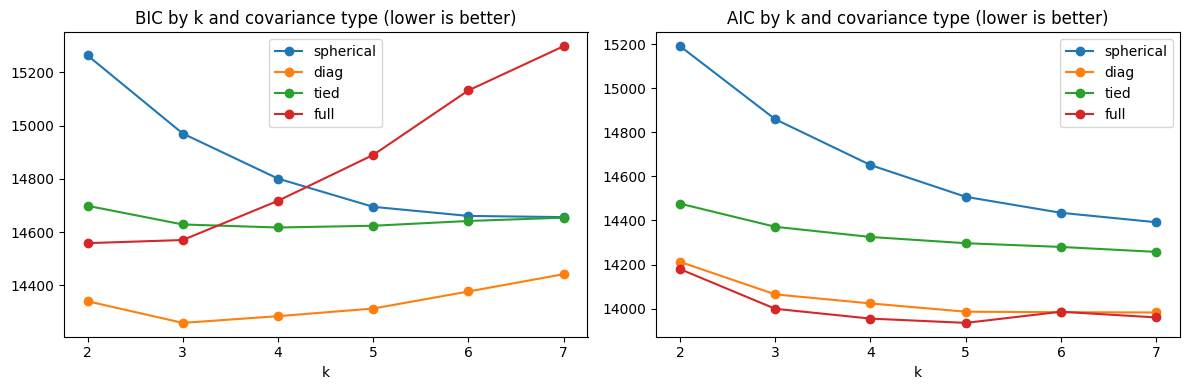

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for covariance_type in covariance_types:
    subset = results_df[results_df['covariance_type'] == covariance_type]
    axes[0].plot(subset['k'], subset['bic'], 'o-', label=covariance_type)
    axes[1].plot(subset['k'], subset['aic'], 'o-', label=covariance_type)
axes[0].set_title('BIC by k and covariance type (lower is better)')
axes[0].set_xlabel('k'); axes[0].legend()
axes[1].set_title('AIC by k and covariance type (lower is better)')
axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout()
plt.show()

In [22]:
best_k = int(best_row['k'])
best_covariance_type = best_row['covariance_type']
print(f"Selected k = {best_k}, covariance_type = '{best_covariance_type}'")

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type=best_covariance_type,
    n_init=20,
    reg_covar=1e-6,
    random_state=RANDOM_STATE
)
gmm_clusters = pd.Series(
    gmm.fit_predict(X),
    index=X_clean.index,
    name='gmm_cluster'
)
gmm_clusters.value_counts().sort_index()

Selected k = 3, covariance_type = 'diag'


,count
gmm_cluster,
0,118
1,47
2,76


In [23]:
silhouette = silhouette_score(X, gmm_clusters)
calinski = calinski_harabasz_score(X, gmm_clusters)
davies = davies_bouldin_score(X, gmm_clusters)

print(f"BIC: {gmm.bic(X):.2f}")
print(f"AIC: {gmm.aic(X):.2f}")
print(f"Silhouette: {silhouette:.4f} (higher is better)")
print(f"Calinski-Harabasz: {calinski:.4f} (higher is better)")
print(f"Davies-Bouldin: {davies:.4f} (lower is better)")

BIC: 14259.65
AIC: 14064.51
Silhouette: 0.2076 (higher is better)
Calinski-Harabasz: 94.0554 (higher is better)
Davies-Bouldin: 1.4997 (lower is better)


In [24]:
probabilities = gmm.predict_proba(X)
maximum_probability = probabilities.max(axis=1)

uncertainty = pd.DataFrame({
    'cluster': gmm_clusters,
    'membership_probability': maximum_probability,
    'uncertain': maximum_probability < 0.70
}, index=X_clean.index)

print(uncertainty.sort_values('membership_probability').head(15))
print("Number of uncertain assignments:", uncertainty['uncertain'].sum())

        cluster  membership_probability  uncertain
Ticker                                            
QLT.L         0                0.537975       True
ENOG.L        1                0.577858       True
USA.L         2                0.599219       True
GDWN.L        2                0.623445       True
ASL.L         0                0.640548       True
RTW.L         0                0.642550       True
AIE.L         0                0.707277      False
MGAM.L        1                0.720711      False
MRC.L         2                0.724236      False
SUPR.L        1                0.753924      False
DOM.L         1                0.803648      False
GSCT.L        2                0.816942      False
QQ.L          2                0.840989      False
IPO.L         0                0.876663      False
FCH.L         2                0.886124      False
Number of uncertain assignments: 6


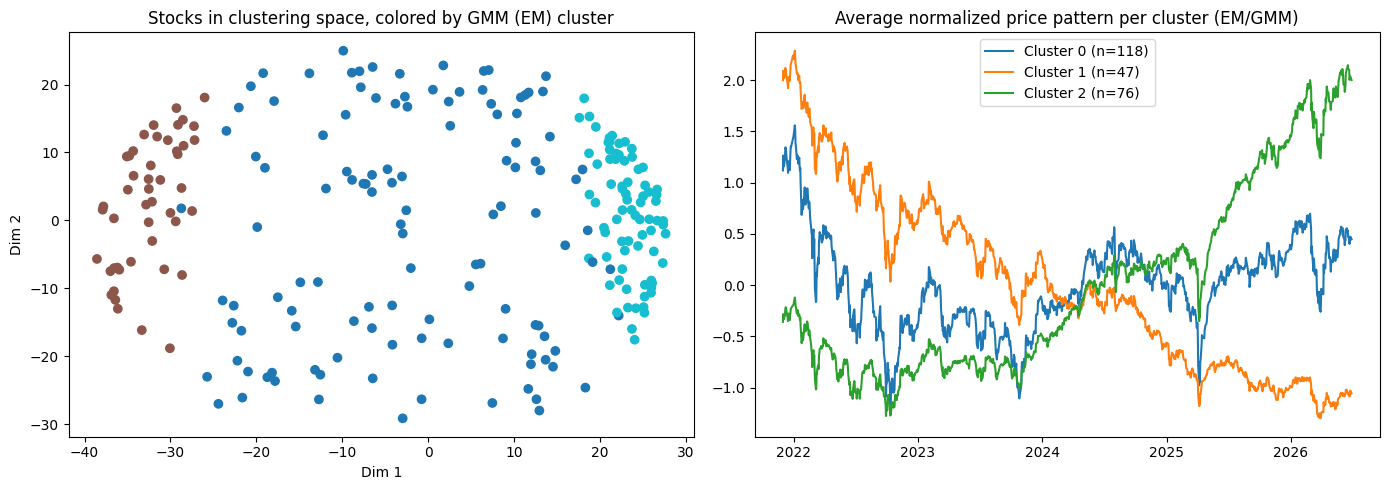

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=gmm_clusters, cmap='tab10')
axes[0].set_title('Stocks in clustering space, colored by GMM (EM) cluster')
axes[0].set_xlabel('Dim 1'); axes[0].set_ylabel('Dim 2')

for c in sorted(gmm_clusters.unique()):
    tickers_in_c = gmm_clusters[gmm_clusters == c].index
    axes[1].plot(X_clean.columns, X_clean.loc[tickers_in_c].mean(axis=0), label=f'Cluster {c} (n={len(tickers_in_c)})')
axes[1].set_title('Average normalized price pattern per cluster (EM/GMM)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [26]:
import textwrap
for c in sorted(gmm_clusters.unique()):
    tickers = sorted(gmm_clusters[gmm_clusters == c].index)
    print(f"Cluster {c} (n={len(tickers)}):")
    print(textwrap.fill(', '.join(tickers), width=100))
    print()

Cluster 0 (n=118):
3IN.L, AIE.L, ALFA.L, AO.L, ASHM.L, ASL.L, BCG.L, BGFD.L, BHMG.L, BKG.L, BMY.L, BOWL.L, BOY.L,
BPT.L, BREE.L, BRGE.L, BRSC.L, BRWM.L, BWY.L, BYIT.L, CGT.L, CKN.L, CMCX.L, COA.L, CORD.L, CSN.L,
CWR.L, DATA.L, DNLM.L, DRX.L, DSCV.L, EMG.L, EWG.L, EWI.L, EZJ.L, FCSS.L, FGP.L, FGT.L, FOUR.L,
FRAS.L, FSG.L, GAMA.L, GEN.L, GFTU.L, GNS.L, GRG.L, GROW.L, HFEL.L, HFG.L, HGT.L, HIK.L, HMSO.L,
HSL.L, HTG.L, HTWS.L, HWG.L, IHP.L, INCH.L, IPO.L, ITV.L, IWG.L, JDW.L, JMAT.L, JSG.L, JUP.L, LRE.L,
MAB.L, MEGP.L, MNTN.L, MONY.L, MRCH.L, MTRO.L, MUT.L, N91.L, NAS.L, NBPE.L, NCC.L, OSB.L, OXB.L,
OXIG.L, PCGH.L, PEY.L, PHI.L, PINT.L, POLN.L, PPH.L, PTEC.L, QLT.L, RAT.L, RCP.L, RHIM.L, RICA.L,
RMV.L, RNK.L, ROR.L, RSW.L, RTW.L, SAGA.L, SAIN.L, SCT.L, SHC.L, SPI.L, SRE.L, SVS.L, TEP.L, TFIF.L,
THRL.L, TRN.L, TRST.L, TRY.L, TW.L, VEIL.L, VOF.L, VSVS.L, VTY.L, WIX.L, WWH.L, ZIG.L

Cluster 1 (n=47):
AML.L, BME.L, BSIF.L, BYG.L, CBG.L, CVSG.L, DLN.L, DOCS.L, DOM.L, ENOG.L, FGEN.L, GBG.L, GCP.

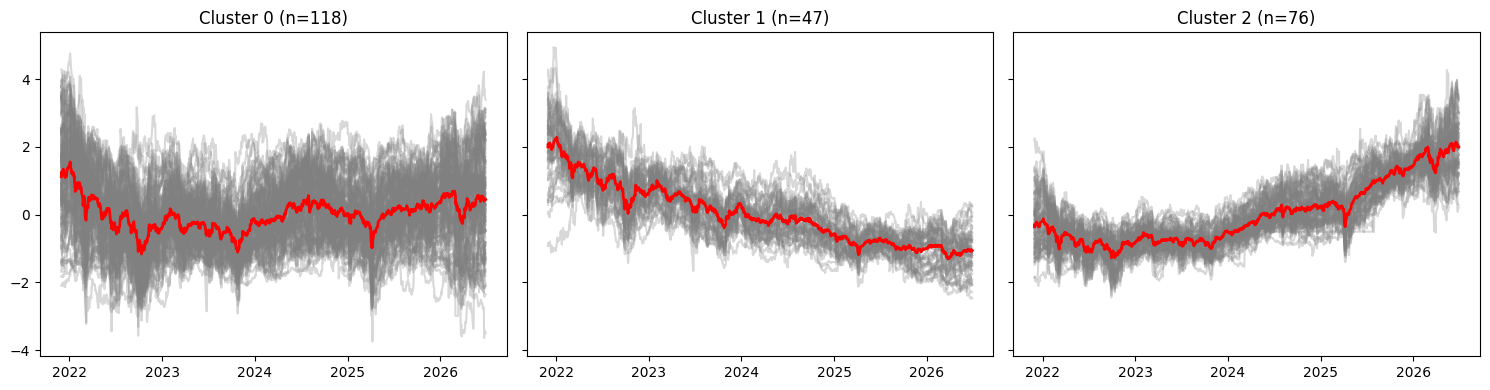

In [27]:
cluster_labels = gmm_clusters

unique_clusters = sorted(cluster_labels.unique())
k = len(unique_clusters)

fig, axes = plt.subplots(1, k, figsize=(5*k, 4), sharey=True)
if k == 1:
    axes = [axes]

for i, c in enumerate(unique_clusters):
    tickers_in_c = cluster_labels[cluster_labels == c].index
    for t in tickers_in_c:
        axes[i].plot(X_clean.columns, X_clean.loc[t], alpha=0.3, color='gray')
    axes[i].plot(X_clean.columns, X_clean.loc[tickers_in_c].mean(axis=0), color='red', linewidth=2)
    title = 'Noise' if c == -1 else f'Cluster {c}'
    axes[i].set_title(f'{title} (n={len(tickers_in_c)})')

plt.tight_layout()
plt.show()

In [28]:
t_idx = np.arange(A.shape[1])
slopes = np.array([np.polyfit(t_idx, row, 1)[0] for row in A])
trend_sign = (slopes > 0).astype(int)

cluster_labels_arr = gmm_clusters.values
ari_trend = adjusted_rand_score(cluster_labels_arr, trend_sign)
print(f"ARI between clusters and sign-of-trend: {ari_trend:.3f}")
print()
if ari_trend > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari_trend > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing something beyond trend direction.")

print(f"\nStocks trending up: {trend_sign.sum()} / down: {(1 - trend_sign).sum()}")
print("\nMean slope per cluster:")
for c in sorted(gmm_clusters.unique()):
    print(f"  Cluster {c}: {slopes[cluster_labels_arr == c].mean():+.6f}")


ARI between clusters and sign-of-trend: 0.254

=> The clustering is capturing something beyond trend direction.

Stocks trending up: 139 / down: 102

Mean slope per cluster:
  Cluster 0: +0.000218
  Cluster 1: -0.002474
  Cluster 2: +0.002407
